# Coursework 1
**Replace CID in the file name with your CID**

# Outline


- [Task 1](#task-1): Linear regression and feature selection <a name="index-task-1"></a>
  - [(1.1)](#task-11) <a name="index-task-11"></a>
  - [(1.2)](#task-12) <a name="index-task-12"></a>
  - [(1.3)](#task-13) <a name="index-task-13"></a>
  - [(1.4)](#task-14) <a name="index-task-14"></a>
- [Task 2](#task-2): Non-linear regression with Kernel Ridge Regression <a name="index-task-2"></a>
  - [(2.1)](#task-21) <a name="index-task-21"></a>
  - [(2.2)](#task-22)  <a name="index-task-22"></a>
- [Task 3](#task-3): Classification with the Multi-Layer Perceptron <a name="index-task-3"></a>
  - [(3.1)](#task-31) <a name="index-task-31"></a>
  - [(3.2)](#task-32)  <a name="index-task-32"></a>



---



<a name="task-1"></a>

# Task 1: Linear regression and feature selection [(index)](#index-task-1)

<a name="task-11"></a>

## (1.1) [(index)](#index-task-11)
Huber function is
\begin{equation}
\phi_c(u)=
\begin{cases}
\dfrac{u^2}{2}, & |u|\le c,\\[6pt]
c(|u|-\dfrac{c}{2}), & |u|>c.
\end{cases}
\end{equation}

For the MSE part,
\begin{equation}
L(g)=\frac{1}{N}\,\|r(g)\|^2
=\frac{1}{N}\,r(g)^{\top}r(g).
\end{equation}

\begin{equation}
\nabla_g L(g)
=\frac{1}{N}\,2\left(\frac{\partial r}{\partial g}\right)^{\top} r.
\end{equation}

Let $Z = X \odot \hat{\beta}^{LS}$
\begin{equation}
\nabla_g L(g)
=\frac{2}{N}\,(-Z)^{\top}r
=-\frac{2}{N}\,Z^{\top}r.
\end{equation}

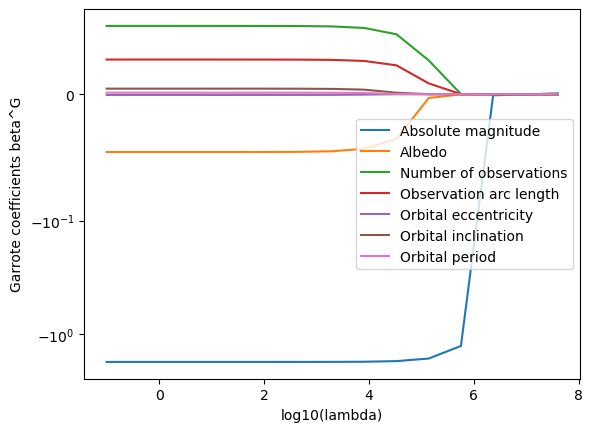

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
rng = np.random.default_rng(0)

df = pd.read_csv("asteroid_observations_train.csv")
target_col = "Asteroid diameter"
y_train = df[target_col].to_numpy(dtype=float)
X_df = df.drop(columns=[target_col]).select_dtypes(include=[np.number])

if target_col in X_df.columns:
    X_df = X_df.drop(columns=[target_col])
    
feature_cols = X_df.columns.tolist()
X_train = X_df.to_numpy(dtype=float)



def standardise(X, X_train_=None):
    """
    Standardise features.

    Parameters:
        X (np.array): Feature matrix.
        X_train_ (np.array): An optional feature matrix to compute the statistics
            from before applying it to X. If None, just use X to compute the statistics.

    Returns:
        X_std (np.array): Standardised feature matrix
    """
    if X_train_ is None:
        X_train_ = X

    mu = np.mean(X_train_, axis=0, keepdims=True)
    sigma = np.std(X_train_, axis=0, keepdims=True)
    X_std = (X - mu) / sigma

    return X_std

def huber_GD(u, c=1e-4):
    """
    Gradient descent of huber function penalty part
    """
    g = np.empty_like(u)
    return  np.where(np.abs(u) < c, u, c * np.sign(u))

def least_square_linear_regression(X,y):
    """
    return parameter beta_LS by ordinary least_square linear regression
    """
    Xb = np.c_[X, np.ones(X.shape[0])]
    beta_LS = np.linalg.lstsq(Xb, y, rcond=None)[0]
    beta_LS_1s = beta_LS[:-1] # beta_LS_1 to beta_LS_p
    beta_LS_0 = beta_LS[-1] # beta_LS_0
    return beta_LS_1s, beta_LS_0

def garrote_gd(X, y, beta_LS_ls, beta_LS_0, lamb, c_huber=1e-4, n_iters=10000, step_size=1e-7):
    N, p = X.shape
    """
    Gradient Descent of garrote part
    """
    Z = X * beta_LS_ls.reshape(1, -1)
    g = np.zeros(p) # start from vector of 1s
    for i in range(n_iters):
        yhat = beta_LS_0 + Z @ g
        r = y - yhat      
        grad_mse = -(2.0 / N) * (Z.T @ r)
        grad_pen = lamb * huber_GD(g, c=c_huber)
        g -= step_size * (grad_mse + grad_pen)
        
    beta_G = g * beta_LS_ls
    return g, beta_G

def garrote(X_train, y_train, lamb_grid=None, c_huber=1e-4, n_iters=10000, step_size=1e-7):
    if lamb_grid is None:
        lamb_grid = np.logspace(-1, 7.6, 15) #set the defaut lambda grid
    
    Xtr = standardise(X_train, X_train_=X_train)
    beta_LS_1s, beta_LS_0 = least_square_linear_regression(Xtr, y_train)
    
    betas = []
    gs = []
    
    for lamb in lamb_grid:
        g, beta_G = garrote_gd(Xtr, y_train, beta_LS_1s, beta_LS_0,
        lamb = lamb, c_huber = c_huber, n_iters = n_iters, step_size = step_size)
        gs.append(g)
        betas.append(beta_G)
    
    betas = np.vstack(betas)
    gs = np.vstack(gs)   
    
    return lamb_grid, betas, gs

def plot_beta_paths(lamb_grid, betas, feature_names=None):
    loglamb = np.log10(lamb_grid)
    p = betas.shape[1]
    if feature_names is None:
        feature_names = [f"x{j+1}" for j in range(p)]

    plt.figure()
    for j in range(p):
        plt.plot(loglamb, betas[:, j], label=feature_names[j])
    plt.xlabel("log10(lambda)")
    plt.ylabel("Garrote coefficients beta^G")
    plt.yscale("symlog", linthresh=0.1)
    plt.legend()
    plt.show()

lamb_grid, betas, gs= garrote(X_train, y_train, lamb_grid=np.logspace(-1, 7.6, 15), c_huber=1e-4, n_iters=10000, step_size=1e-7)
plot_beta_paths(lamb_grid, betas, feature_names=feature_cols)
plt.show()

<a name="task-12"></a>

## (1.2) [(index)](#index-task-12)

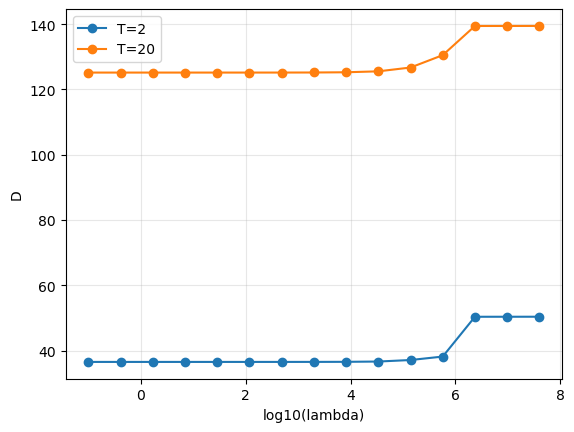

In [8]:
def folds_no_shuffle(N, T):
    """
    Split indices into T consecutive folds, no shuffle
    """
    return np.array_split(np.arange(N), T)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def garrote_mse_on_fold(X, y, train_idx, val_idx, lamb, c_huber = 1e-4, n_iters = 10000, step_size = 1e-7):
    """
    runs one cross validation fold and calculate the validation MSE for the fold 
    """
    X_tr, y_tr = X[train_idx], y[train_idx]
    X_va, y_va = X[val_idx], y[val_idx] # Split the data into train and validation folds

    X_tr_std = standardise(X_tr, X_train_=X_tr)
    X_va_std = standardise(X_va, X_train_=X_tr)

    # Ordinary least square linear regression on train set
    beta_LS_1s, beta_LS_0 = least_square_linear_regression(X_tr_std, y_tr)

    g, beta_G = garrote_gd(
        X_tr_std, y_tr,
        beta_LS_1s, beta_LS_0,
        lamb=lamb, c_huber=c_huber, n_iters=n_iters, step_size=step_size)# Garrote on train fold

    # validation prediction + MSE
    yhat_va = beta_LS_0 + X_va_std @ beta_G # Execute on the validation set
    return mse(y_va, yhat_va)

def D_curve(X_train, y_train, T, lamb_grid, c_huber = 1e-4, n_iters = 10000, step_size = 1e-7):
    """
    Run cross validation for each lambda in lamb_grid, returns D and validation MSE for each fold
    """
    N = X_train.shape[0]
    folds = folds_no_shuffle(N, T)
    n_lam = len(lamb_grid)
    MSE_folds = np.zeros((n_lam, T)) # a matrix of shape (n_lam, T)
    
    for t in range(T):
        val_idx = folds[t]
        train_idx = np.hstack([folds[k] for k in range(T) if k != t])
        for k, lamb in enumerate(lamb_grid):
            MSE_folds[k, t] = garrote_mse_on_fold(X_train, y_train, train_idx, val_idx, lamb, 
                                                  c_huber=c_huber, n_iters=n_iters, step_size=step_size)
    D = np.mean(np.abs(MSE_folds[:, 1:] - MSE_folds[:, :-1]), axis=1)
    return D, MSE_folds

lamb_grid = np.logspace(-1, 7.6, 15)
loglamb = np.log10(lamb_grid)


D2,  MSE2  = D_curve(X_train, y_train, T = 2,  lamb_grid = lamb_grid,
                             c_huber = 1e-4, n_iters = 10000, step_size = 1e-7)
D20, MSE20 = D_curve(X_train, y_train, T = 20, lamb_grid = lamb_grid,
                             c_huber = 1e-4, n_iters = 10000, step_size = 1e-7)

plt.figure()
plt.plot(loglamb, D2,  marker="o", label="T=2")
plt.plot(loglamb, D20, marker="o", label="T=20")
plt.xlabel("log10(lambda)")
plt.ylabel("D")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<a name="task-13"></a>

## (1.3) [(index)](#index-task-13)

Consider the MSE part, similar to task 1.1
\begin{equation}
\nabla_g L(g)
=\frac{1}{N}\,2\left(\frac{\partial r}{\partial g}\right)^{\top} r.
\end{equation}

Since
$r = y - \beta_0 \mathbf{1} - X\beta$

we have
$\frac{\partial r}{\partial \beta} = -X$

So we have
\begin{equation}
\nabla_{\beta} L
= \frac{1}{N}\, 2(-X)^{\top} r
= -\frac{2}{N} X^{\top} r
\end{equation}

The penalty part is similar to task 1.1

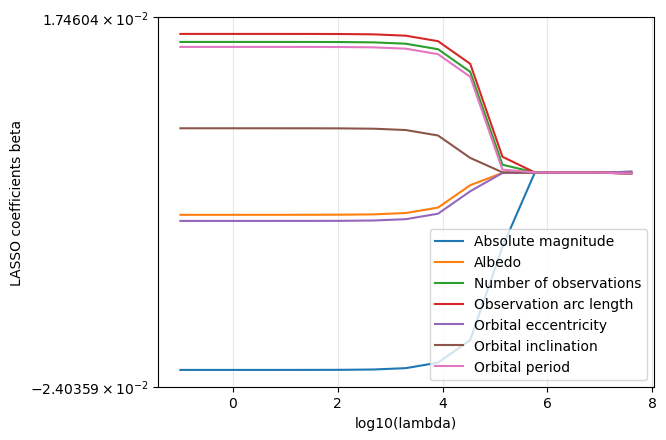

In [9]:
lamb_grid = np.logspace(-1, 7.6, 15)
loglamb = np.log10(lamb_grid)

X_std = standardise(X_train, X_train_=X_train)
Ntrain, p = X_std.shape

def lasso_gd(X, y, lamb, c_huber=1e-4, n_iters=10000, step_size=1e-7,
            beta_init=None, beta0_init=0.0):
    
    N, p = X.shape
    beta = np.zeros(p)
    beta0 = float(beta0_init)
    XT = X.T
    for i in range(n_iters):
        yhat = beta0 + X @ beta
        r = y - yhat
        
        # GD for the MSE part
        grad_beta  = -(2.0 / N) * (XT @ r)
        grad_beta0 = -(2.0 / N) * np.sum(r)
        
        # GD for the penalty part
        grad_pen = lamb * huber_GD(beta, c = c_huber)

        beta  -= step_size * (grad_beta + grad_pen)
        beta0 -= step_size * grad_beta0

    return beta, beta0

def lasso_coef_trajectory(X, y, lamb_grid, c_huber = 1e-4, n_iters = 10000, step_size = 1e-7):
    betas = np.zeros((len(lamb_grid), X.shape[1]))
    beta_prev = np.zeros(X.shape[1])
    beta0_prev = 0.0
    
    for k, lamb in enumerate(lamb_grid):
        beta_prev, beta0_prev = lasso_gd(X, y, lamb, c_huber = c_huber, n_iters = n_iters, step_size = step_size,
            beta_init = beta_prev, beta0_init = beta0_prev)
        betas[k] = beta_prev
        
    return betas

betas_lasso = lasso_coef_trajectory(X_std, y_train, lamb_grid, c_huber=1e-4, n_iters=10000, step_size=1e-7)

plt.figure()
for j in range(p):
    plt.plot(loglamb, betas_lasso[:, j], label=feature_cols[j])
plt.xlabel("log10(lambda)")
plt.ylabel("LASSO coefficients beta")
plt.yscale("symlog", linthresh=0.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


The trend of weights of all features with respect to change of $\lambda$ is similar in 1.1 and 1.3. Weights of Absolute magnitude, Albedo and number of observations are similar in both task. Weight of observation arc length decreases a lot in 1.3. 

\begin{equation}
\pi_j(\lambda) \;=\; \frac{1}{B}\sum_{b=1}^{B}\mathbf{1}\!\left(\left|\beta^{(b)}_{j}(\lambda)\right|>\text{thresh}\right)
\end{equation}

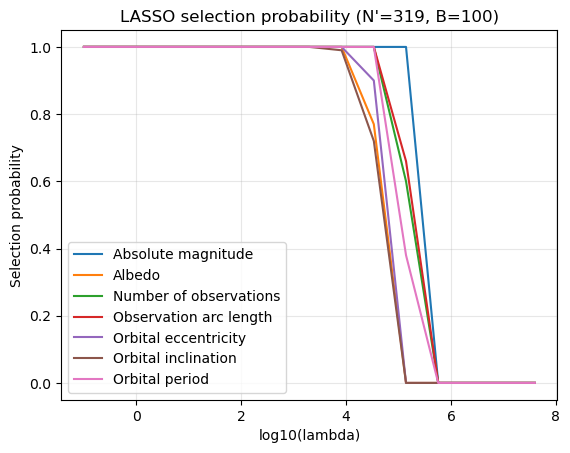

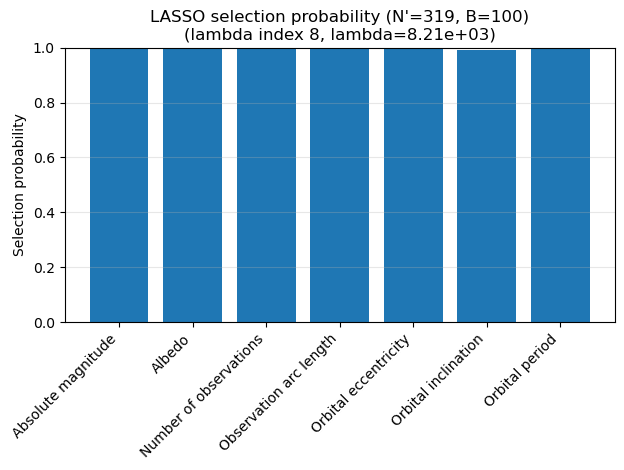

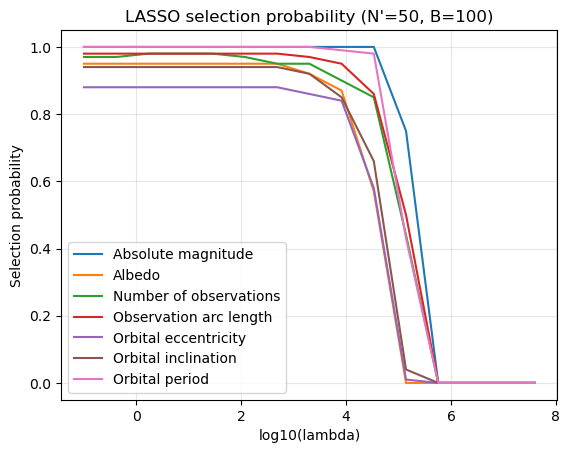

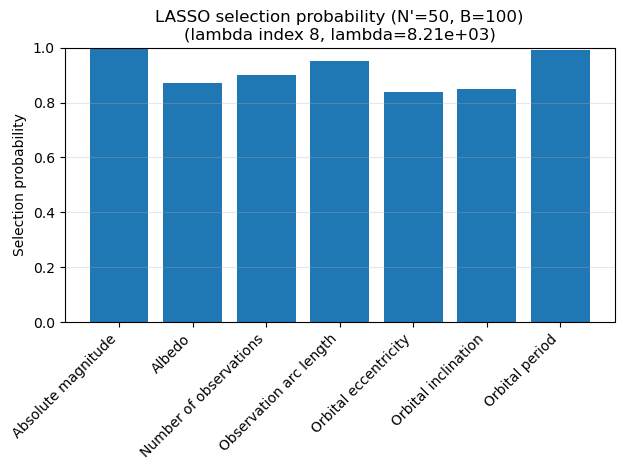

In [20]:
def selection_prob_lasso_bootstrap(X_std, y, lamb_grid, Nprime, B = 100, 
                                   c_huber = 1e-4, n_iters = 10000, step_size = 1e-7,thresh = 1e-3):
    N, p = X_std.shape
    counts = np.zeros((len(lamb_grid),p), dtype = float) # To store the selected times of each feature
    
    for i in range(B):
        idx = rng.choice(N, size=Nprime, replace=False) # Index of x's chosen in bootstrap
        Xb = X_std[idx]
        yb = y[idx]
        
        betas_b = lasso_coef_trajectory(Xb, yb, lamb_grid = lamb_grid, c_huber = c_huber,
                                        n_iters = n_iters, step_size = step_size)
        
        counts += (np.abs(betas_b) > thresh).astype(float)
    return counts / B
    
def plot_selection_prob_paths(probs, title):
    plt.figure()
    for j in range(probs.shape[1]):
        plt.plot(loglamb, probs[:, j], label=feature_cols[j])
    plt.xlabel("log10(lambda)")
    plt.ylabel("Selection probability")
    plt.ylim(-0.05, 1.05)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
def barplot_selection_probs(probs, idx=8, title=""):
    plt.figure()
    plt.bar(feature_cols, probs[idx])
    plt.ylim(0, 1)
    plt.ylabel("Selection probability")
    plt.title(f"{title}\n(lambda index {idx}, lambda={lamb_grid[idx]:.3g})")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    
B = 100
idx_bar = 8
for Nprime in [Ntrain // 2, 50]:
    probs = selection_prob_lasso_bootstrap(
        X_std, y_train, lamb_grid, Nprime=Nprime, B=B,
        c_huber=1e-4, n_iters=10000, step_size=1e-7, thresh=1e-3
    )
    plot_selection_prob_paths(probs, title=f"LASSO selection probability (N'={Nprime}, B={B})")
    barplot_selection_probs(probs, idx=idx_bar, title=f"LASSO selection probability (N'={Nprime}, B={B})")


For small $\lambda$, all features are almost selected. As $\lambda$ increases, the curves drop sharply toward $0$. For larger $N'$, coefficients are more consistent, selection probability is more stable. For smaller $N'$, selection probability is less stable because it is more sensitive to sampling.

<a name="task-14"></a>

## (1.4) [(index)](#index-task-14)

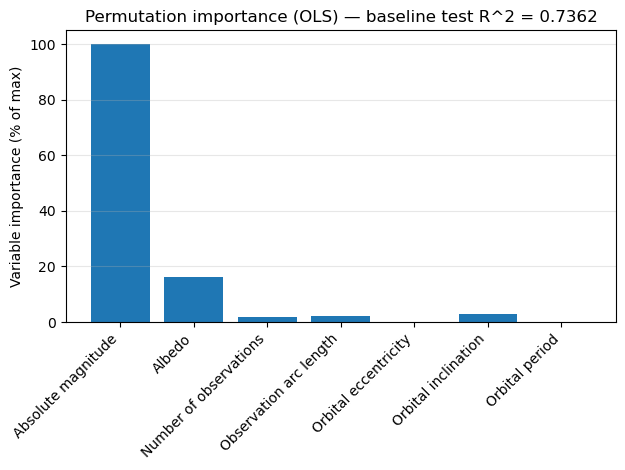

Baseline test R^2: 0.7362124940498774
       Absolute magnitude: 100.00%   (|ΔR^2|=0.828802)
                   Albedo:  16.07%   (|ΔR^2|=0.133160)
      Orbital inclination:   2.76%   (|ΔR^2|=0.022904)
   Observation arc length:   2.07%   (|ΔR^2|=0.017138)
   Number of observations:   1.86%   (|ΔR^2|=0.015441)
     Orbital eccentricity:   0.17%   (|ΔR^2|=0.001406)
           Orbital period:   0.06%   (|ΔR^2|=0.000463)


In [29]:
df_test = pd.read_csv("asteroid_observations_test.csv")
target_col = "Asteroid diameter"
def standardise(X, X_train_=None):
    """
    Standardise features.

    Parameters:
        X (np.array): Feature matrix.
        X_train_ (np.array): An optional feature matrix to compute the statistics
            from before applying it to X. If None, just use X to compute the statistics.

    Returns:
        X_std (np.array): Standardised feature matrix
    """
    if X_train_ is None:
        X_train_ = X

    mu = np.mean(X_train_, axis=0, keepdims=True)
    sigma = np.std(X_train_, axis=0, keepdims=True)
    X_std = (X - mu) / sigma

    return X_std
y_test = df_test[target_col].to_numpy(dtype=float)
X_test_df = df_test.drop(columns=[target_col]).select_dtypes(include=[np.number])
if target_col in X_test_df.columns:
    X_test_df = X_test_df.drop(columns=[target_col])
    
feature_cols = X_test_df.columns.tolist()
X_test = X_test_df.to_numpy(dtype=float)

Xtr_std = standardise(X_train, X_train_=X_train)
Xte_std = standardise(X_test,  X_train_=X_train)

beta_LS_1s, beta_LS_0 = least_square_linear_regression(Xtr_std, y_train)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1.0 - ss_res/ss_tot

# Baseline R^2 on test
yhat_base = beta_LS_0 + Xte_std @ beta_LS_1s
R2_base = r2_score(y_test, yhat_base)


p = Xte_std.shape[1]
importances = np.zeros(p)

for j in range(p):
    Xperm = Xte_std.copy()
    Xperm[:, j] = rng.permutation(Xperm[:, j])   # Shuffle only column j

    yhat_perm = beta_LS_0 + Xperm @ beta_LS_1s
    R2_perm_j = r2_score(y_test, yhat_perm)

    importances[j] = abs(R2_base - R2_perm_j)

imp_pct = 100.0 * importances / np.max(importances)

# Plot
plt.figure()
plt.bar(feature_cols, imp_pct)
plt.ylabel("Variable importance (% of max)")
plt.title(f"Permutation importance (OLS) — baseline test R^2 = {R2_base:.4f}")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: print ranked importances
order = np.argsort(-imp_pct)
print("Baseline test R^2:", R2_base)
for k in order:
    print(f"{feature_cols[k]:>25s}: {imp_pct[k]:6.2f}%   (|ΔR^2|={importances[k]:.6f})")

Permutation importance (OLS) gives baseline test $R^2=0.7362$ and shows Absolute magnitude dominates predictive performance, with Albedo a distant second and the other features contributing little. This matches the Garrote paths, where coefficients shrink towards zero as 
$\lambda$ increases. Compared to bar chart of $N'=50$, weaker features are more sensitive to sampling noise, while the dominant features remain the most robust

<a name="task-2"></a>

# Task 2: Non-linear regression with Kernel Ridge Regression [(index)](#index-task-2)

<a name="task-21"></a>

## (2.1) [(index)](#index-task-21)

Denote,
$X_b = \bigl[\, X \ \mathbf{1} \,\bigr]$,
$w =
\begin{bmatrix}
\beta \\
\beta_0
\end{bmatrix}.
$

We have,
$L(w) = \lVert y - X_b w \rVert^2 + \lambda\, w^\top I w $.

So, $\nabla_w L(w) = -2X_b^\top (y - X_b w) + 2\lambda Iw .$


In [32]:
def r2_score(y_true, y_pred):
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot

def standardise(X, X_train_=None):
    if X_train_ is None:
        X_train_ = X
    mu = np.mean(X_train_, axis=0, keepdims=True)
    sigma = np.std(X_train_, axis=0, keepdims=True)
    X_std = (X - mu) / sigma
    return X_std, mu, sigma

def ridge_with_intercept(X_train, y_train, lamb=0.1):
    """
    ridge regression with intercept
    """
    N, p = X_train.shape
    Xb = np.c_[X_train, np.ones(N)] # Matrix of size(N, p+1)

    I = np.eye(p+1)
    I[-1, -1] = 0.0  # don't penalise on beta_0

    w = np.linalg.solve(Xb.T @ Xb + lamb * N* I, Xb.T @ y_train) # Gredient of L is 0
    beta = w[:-1]
    beta0 = w[-1]
    return beta, beta0

def predict_linear(X, beta, beta0):
    return X @ beta + beta0

lamb = 0.1

Xtr_std, mu, sigma = standardise(X_train, X_train_= X_train)
Xte_std, mute, sigmate = standardise(X_test,  X_train_= X_train)

beta, beta0 = ridge_with_intercept(Xtr_std, y_train, lamb = lamb)

yhat_tr = predict_linear(Xtr_std, beta, beta0)
yhat_te = predict_linear(Xte_std, beta, beta0)

print("Ridge (primal) lamb=0.1")
print("Train R^2:", r2_score(y_train, yhat_tr))
print("Test  R^2:", r2_score(y_test,  yhat_te))


Ridge (primal) lamb=0.1
Train R^2: 0.750465814764694
Test  R^2: 0.7460360911430929


Set $\beta_0=0$, we get

\begin{equation}
f(x) = \phi(x)^\top w .
\end{equation}

The loss function is
\begin{equation}
L = \frac{1}{N}\sum_{i=1}^{N}\bigl(y_i - \phi(x_i)^\top w\bigr)^2 + \lambda \lVert w\rVert^2 .
\end{equation}

Let
\begin{equation}
w = \sum_{i=1}^{N} \alpha_i\, \phi(x_i).
\end{equation}

So we have
\begin{equation}
\begin{aligned}
f(x_j)
&= \phi(x_j)^\top w \\
&= \sum_{i=1}^{N}\alpha_i\, \phi(x_j)^\top \phi(x_i) \\
&= \sum_{i=1}^{N}\alpha_i\, k(x_j, x_i),
\end{aligned}
\end{equation}

We need
\begin{equation}
k(x,z) = \phi(x)^T\phi(z).
\end{equation}

Define
\begin{equation}
K \in \mathbb{R}^{N\times N}, \qquad K_{ji} = k(x_j, x_i).
\end{equation}

Then we have
\begin{equation}
f = K\alpha.
\end{equation}

\begin{equation}
\lVert w\rVert^2 = \alpha^\top K \alpha.
\end{equation}

KKR is 
\begin{equation}
L = \frac{1}{N}\,\lVert y - K\alpha\rVert^2 + \lambda\, \alpha^\top K\alpha .
\end{equation},

where \begin{equation}
\alpha = (K + \lambda N I)^{-1}y.
\end{equation}

In [33]:
def poly_kernel(A, B, n=2, c=0.0):
    return (A @ B.T + c) ** n

def krr_fit(X_train_std, y_train, lamb = 0.1, n = 2, c = 0.0, jitter = 1e-10):
    N = X_train_std.shape[0]
    K = poly_kernel(X_train_std, X_train_std, n = n, c = c)
    A = K + (N * lamb) * np.eye(N) + jitter * np.eye(N)
    alpha = np.linalg.solve(A, y_train)
    return alpha

def krr_predict(X_train_std, X_eval_std, alpha, n = 2, c = 0.0):
    K_eval = poly_kernel(X_eval_std, X_train_std, n = n, c = c)
    return K_eval @ alpha

lamb = 0.1
settings = [(2, 0.0), (2, 1.0), (3, 1.0)]

print("KRR (beta0=0), lambda = 0.1")
for deg, c0 in settings:
    alpha = krr_fit(Xtr_std, y_train, lamb=lamb, n=deg, c=c0)
    yhat_tr = krr_predict(Xtr_std, Xtr_std, alpha, n=deg, c=c0)
    yhat_te = krr_predict(Xtr_std, Xte_std, alpha, n=deg, c=c0)

    print(f"\nPolynomial kernel: n={deg}, c={c0}")
    print("Train R^2:", r2_score(y_train, yhat_tr))
    print("Test  R^2:", r2_score(y_test,  yhat_te))

KRR (beta0=0), lambda = 0.1

Polynomial kernel: n=2, c=0.0
Train R^2: 0.7442772950232918
Test  R^2: 0.6175788574986489

Polynomial kernel: n=2, c=1.0
Train R^2: 0.9532555877132383
Test  R^2: 0.9477435915124091

Polynomial kernel: n=3, c=1.0
Train R^2: 0.9843306895540554
Test  R^2: 0.9759929264269496


$R^2$ in KRR is for (2,1) and (3,1) is much larger than $R^2$ in linear ridge. Poly KRR (c=1) implicitly adds nonlinear and lower-order terms 
so it is much better than linear ridge.

<a name="task-22"></a>

## (2.2) [(index)](#index-task-22)


===== lambda = 0.1 =====
Poly kernel (n=2,c=1)      Train R^2: 0.950370


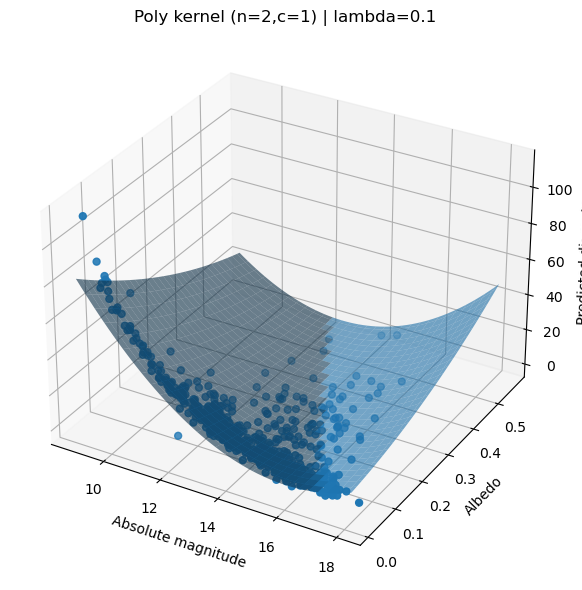

RBF kernel (sigma=20)      Train R^2: 0.421963


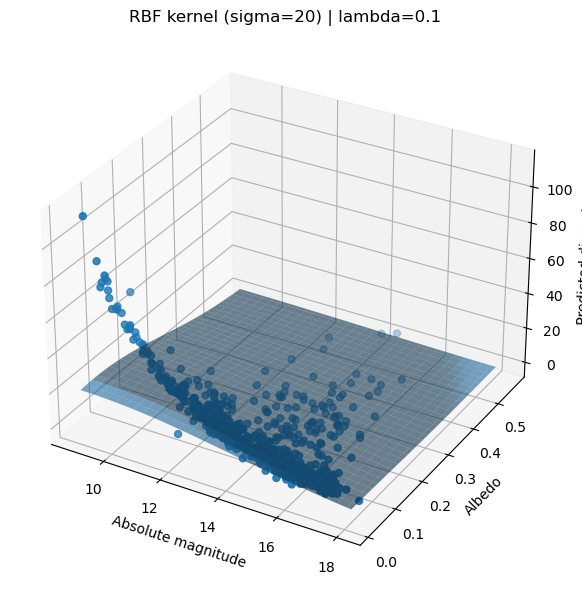

New kernel (RBF on phi)    Train R^2: 0.396055


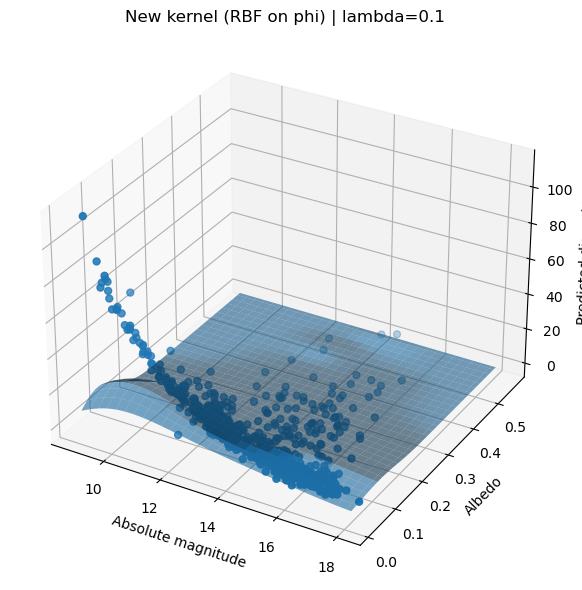


===== lambda = 300.0 =====
Poly kernel (n=2,c=1)      Train R^2: -0.745609


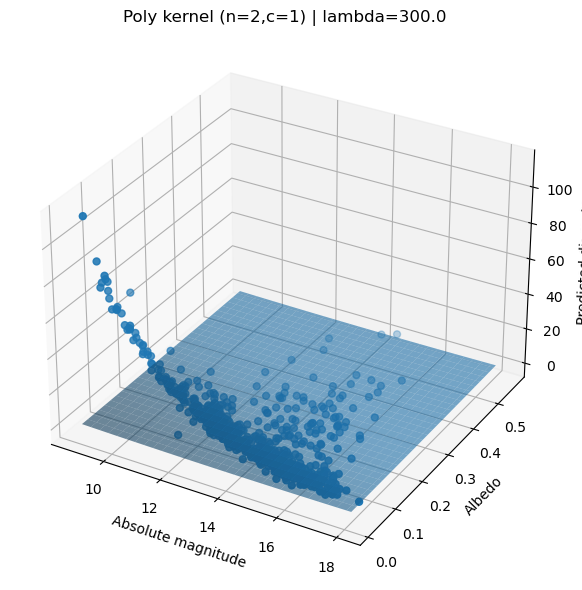

RBF kernel (sigma=20)      Train R^2: -0.780351


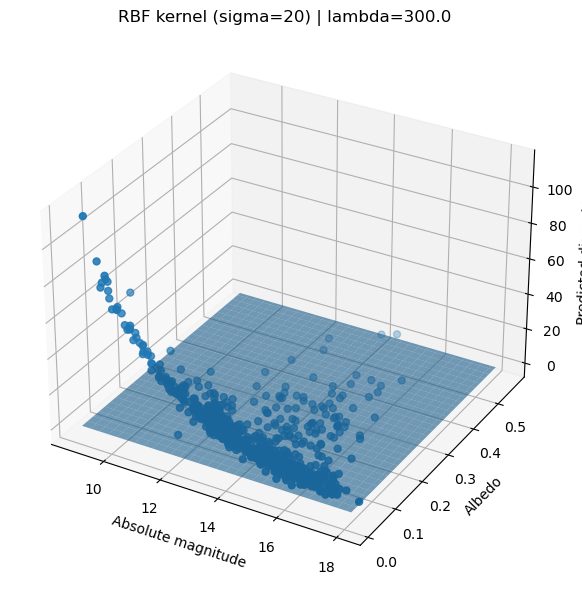

New kernel (RBF on phi)    Train R^2: -0.782037


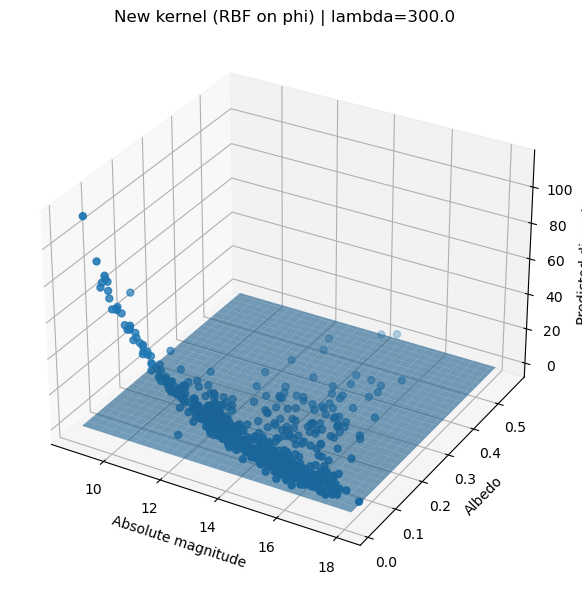

In [40]:
# pick 2 features: Absolute magnitude + Albedo
i_abs = feature_cols.index("Absolute magnitude")
i_alb = feature_cols.index("Albedo")

X2_train = X_train[:, [i_abs, i_alb]]
ytr = y_train.reshape(-1)

# standardise based on train itself
X2_tr_std, mu2, sig2 = standardise(X2_train, X_train_=X2_train)

def poly_kernel_n2_c1(X, Y):
    """
    Polynomial kernel (n=2, c=1): (x·y + 1)^2
    """
    return (X @ Y.T + 1.0) ** 2

def rbf_kernel_sigma(X, Y, sigma=20.0):
    """
    RBF kernel: exp(-||x-y||^2 / sigma)
    """
    X_sq = np.sum(X**2, axis=1, keepdims=True)        # (N,1)
    Y_sq = np.sum(Y**2, axis=1, keepdims=True).T      # (1,M)
    dist2 = X_sq + Y_sq - 2.0 * (X @ Y.T)             # (N,M)
    return np.exp(-dist2 / sigma)

def new_kernel(X, Y, sigma=20.0):
    """
    k_new(v,z) = exp(-||phi(v)-phi(z)||^2 / sigma)
    where <phi(v),phi(z)> = (v·z + 1)^2
    so ||phi(v)-phi(z)||^2 = kP(v,v) + kP(z,z) - 2 kP(v,z)
    """
    Kp = poly_kernel_n2_c1(X, Y)
    diagX = (np.sum(X**2, axis=1) + 1.0) ** 2         # kP(x,x)
    diagY = (np.sum(Y**2, axis=1) + 1.0) ** 2         # kP(y,y)
    dist2_phi = diagX[:, None] + diagY[None, :] - 2.0 * Kp
    return np.exp(-dist2_phi / sigma)

def krr_fit_alpha(K_train, y, lamb):
    """
    Solve (K + N*lambda*I) alpha = y
    """
    N = K_train.shape[0]
    A = K_train + (N * lamb) * np.eye(N)
    alpha = np.linalg.solve(A, y)
    return alpha

def krr_predict(K_test_train, alpha):
    """
    yhat = K_test_train alpha
    """
    return K_test_train @ alpha

def plot_krr_surface(X_raw_2, y, X_tr_std, mu, sig, alpha, kfun, name, lamb, grid_n=60):
    """
    3D plot: x1,x2 are raw (unstandardised), z is predicted y
    """
    x1 = X_raw_2[:, 0]
    x2 = X_raw_2[:, 1]

    x1_grid = np.linspace(x1.min(), x1.max(), grid_n)
    x2_grid = np.linspace(x2.min(), x2.max(), grid_n)
    X1g, X2g = np.meshgrid(x1_grid, x2_grid)

    Xg_raw = np.c_[X1g.ravel(), X2g.ravel()]
    Xg_std = (Xg_raw - mu) / sig

    K_g_tr = kfun(Xg_std, X_tr_std)                 
    yhat_g = (K_g_tr @ alpha).reshape(grid_n, grid_n)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X1g, X2g, yhat_g, alpha=0.6, linewidth=0)
    ax.scatter(x1, x2, y, s=25)

    ax.set_xlabel("Absolute magnitude")
    ax.set_ylabel("Albedo")
    ax.set_zlabel("Predicted diameter")
    ax.set_title(f"{name} | lambda={lamb}")
    plt.tight_layout()
    plt.show()

sigma = 20.0
kernels = [
    ("Poly kernel (n=2,c=1)", lambda A, B: poly_kernel_n2_c1(A, B)),
    ("RBF kernel (sigma=20)", lambda A, B: rbf_kernel_sigma(A, B, sigma=sigma)),
    ("New kernel (RBF on phi)", lambda A, B: new_kernel(A, B, sigma=sigma)),
]

lamb_list = [0.1, 300.0]

for lamb in lamb_list:
    print(f"\n===== lambda = {lamb} =====")
    for name, kfun in kernels:
        K_tr = kfun(X2_tr_std, X2_tr_std)            # (N,N)
        alpha = krr_fit_alpha(K_tr, ytr, lamb=lamb)

        yhat_tr = krr_predict(K_tr, alpha)
        r2_tr = r2_score(ytr, yhat_tr)
        print(f"{name:25s}  Train R^2: {r2_tr:.6f}")

        plot_krr_surface(
            X_raw_2 = X2_train, y = ytr,
            X_tr_std = X2_tr_std, mu = mu2, sig = sig2,
            alpha = alpha, kfun = kfun,
            name = name, lamb = lamb, grid_n = 60
        )


When $\lambda = 300$, $R^2$ are all negative. This is caused by the heavy penalty on the regression, which is hard for the model to fit the data. The polynomial kernelised Ridge regression has the highest $R^2$ so it has the highest fitting power.

<a name="task-3"></a>

# Task 3: Classification with the Multi-Layer Perceptron [(index)](#index-task-3)

<a name="task-31"></a>

## (3.1) [(index)](#index-task-31)

In [3]:
# Define MLP class
def dense(X, W, b):
    """Full-connected MLP layer.

    Parameters:
        X (np.ndarray): input matrix, shape (N, p)
        W (np.ndarray): weights, shape (m, p)
        b (np.ndarray): bias, shape (m,)

    Returns:
        a (np.ndarray): pre-activations, shape (N, m)
    """
    a = np.vstack([W @ x + b for x in X])
    return a

def relu_activation(a):
    """ReLU activation function."""
    h = a.copy()
    h[h < 0] = 0
    return h

def grad_relu_activation(a):
    """Gradient of ReLU activation function."""
    grad = np.zeros_like(a)
    grad[a > 0] = 1
    return grad

def tanh_activation(a):
    """Tanh activation function."""
    return np.tanh(a)

def grad_tanh_activation(a):
    """Gradient of tanh activation function."""
    return 1 - np.tanh(a) ** 2

def sigmoid_activation(a):
    """Sigmoid activation function."""
    out = np.zeros_like(a)
    pos = (a >= 0)
    neg = ~pos
    out[pos] = 1 / (1 + np.exp(-a[pos]))
    expa = np.exp(a[neg])
    out[neg] = expa / (1 + expa)
    return out

def grad_sigmoid_activation(a):
    """Gradient of sigmoid activation."""
    s = sigmoid_activation(a)
    return s * (1 - s)

activation_table = {
    "relu": relu_activation,
    "sigmoid": sigmoid_activation,
    "tanh": tanh_activation,
    "identity": lambda x: x
}

grad_activation_table = {
    "relu": grad_relu_activation,
    "sigmoid": grad_sigmoid_activation,
    "tanh": grad_tanh_activation,
    "identity": lambda x: np.ones_like(x)
}

class MLP:
    """
    Multi-Layer Perceptron (MLP) class from Week 5 notebook.
    """

    def __init__(self, seed=0):
        self.layers = []
        self.rng = np.random.default_rng(seed)

    def n_layers(self):
        """Return current number of MLP layers (including input and output)."""
        return len(self.layers) + 1

    def layer_dim(self, index):
        """Retrieve the dimensions of the MLP layer at `index`."""
        if index == 0:
            return self.layers[0]["in_dim"]
        if index == len(self.layers):
            return self.layers[-1]["out_dim"]
        return self.layers[index]["in_dim"]

    def add_layer(self, in_dim, out_dim, activation="identity"):
        """Add fully connected layer to MLP."""
        W = self.rng.standard_normal((out_dim, in_dim)) * np.sqrt(2 / in_dim)
        b = np.zeros(out_dim)

        self.layers.append({
            "in_dim": in_dim,
            "out_dim": out_dim,
            "activation": activation,
            "W": W,
            "b": b
        })

    def n_parameters(self):
        """Return number of trainable parameters."""
        total = 0
        for layer in self.layers:
            total += layer["W"].size + layer["b"].size
        return total

    def predict(self, X):
        """
        Forward pass.
        Returns:
            y_hat (np.ndarray): output of last layer (logits)
            forward_pass (list): computation graph
        """
        forward_pass = []
        h = X

        # node 0: input
        forward_pass.append({"h": h})

        for k in range(len(self.layers)):
            W = self.layers[k]["W"]
            b = self.layers[k]["b"]

            a = dense(h, W, b)
            activation = activation_table[self.layers[k]["activation"]]
            h = activation(a)

            forward_pass.append({"a": a, "h": h})

        y_hat = forward_pass[-1]["h"]
        return y_hat, forward_pass

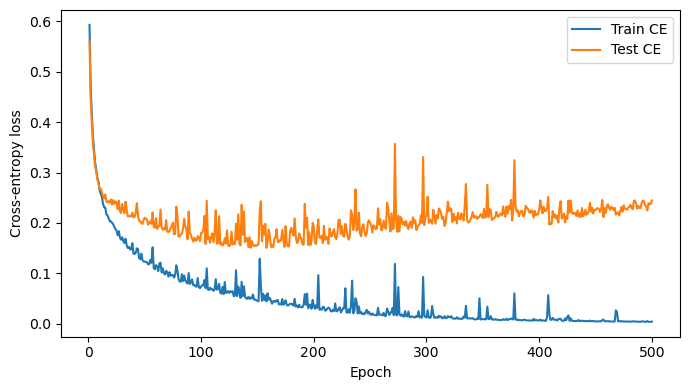

In [4]:
rng = np.random.default_rng(0)


df = pd.read_csv("asteroid_observations_train.csv")
FEATURES = [
    "Absolute magnitude",
    "Albedo",
    "Number of observations",
    "Observation arc length",
    "Orbital eccentricity",
    "Orbital inclination",
    "Orbital period",
]

CLASSES = ["MBA", "OMB", "TJN"]
MAP_TO_INT = {c: i for i, c in enumerate(CLASSES)}

X = df[FEATURES].to_numpy(dtype=np.float32)
y_str = df["Asteroid class"].astype(str).to_numpy()
y = np.array([MAP_TO_INT[s] for s in y_str], dtype=int)

def standardise(X, X_train_=None):
    if X_train_ is None:
        X_train_ = X
    mu = np.mean(X_train_, axis=0, keepdims=True)
    sigma = np.std(X_train_, axis=0, keepdims=True)
    sigma = np.where(sigma == 0, 1.0, sigma)  # safety
    X_std = (X - mu) / sigma
    return X_std, mu, sigma

def stratified_split(y, train_frac=0.8, seed=42):
    r = np.random.default_rng(seed)
    train_idx, test_idx = [], []
    for c in np.unique(y):
        idx = np.where(y == c)[0]
        idx = r.permutation(idx)
        n_train = int(round(train_frac * len(idx)))
        train_idx.extend(idx[:n_train])
        test_idx.extend(idx[n_train:])
    train_idx = r.permutation(np.array(train_idx, dtype=int))
    test_idx  = r.permutation(np.array(test_idx, dtype=int))
    return train_idx, test_idx

def softmax(logits):
    m = np.max(logits, axis=1, keepdims=True)
    exp = np.exp(logits - m)
    return exp / np.sum(exp, axis=1, keepdims=True)

def ce_mean(p, y, eps=1e-12):
    return -np.mean(np.log(p[np.arange(len(y)), y] + eps))

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def per_class_accuracy(y_true, y_pred, n_classes=3):
    accs = np.zeros(n_classes, dtype=float)
    for q in range(n_classes):
        mask = (y_true == q)
        accs[q] = np.mean(y_pred[mask] == y_true[mask]) if np.any(mask) else np.nan
    return accs

def backprop_classification(mlp, forward_pass, dlogits):
    """
    Backprop for MLP 
    """
    L = len(mlp.layers)
    K = dlogits.shape[0]

    grads_W = [None] * L
    grads_b = [None] * L


    h_prev = forward_pass[-2]["h"]
    W_last = mlp.layers[-1]["W"] 

    grads_W[-1] = (dlogits.T @ h_prev) / K
    grads_b[-1] = np.mean(dlogits, axis=0)

    dh = dlogits @ W_last 


    for j in range(L-2, -1, -1):
        a_j = forward_pass[j+1]["a"]
        h_prev = forward_pass[j]["h"]
        W_j = mlp.layers[j]["W"]

        act_name = mlp.layers[j]["activation"]
        dact = grad_activation_table[act_name](a_j)

        da = dh * dact

        grads_W[j] = (da.T @ h_prev) / K
        grads_b[j] = np.mean(da, axis=0)

        dh = da @ W_j                       # (K, in_j)

    grads = [{"W": grads_W[k], "b": grads_b[k]} for k in range(L)]
    return grads

train_idx, test_idx = stratified_split(y, train_frac=0.8, seed=42)
X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]


X_train, mu, sigma = standardise(X_train)
X_test = (X_test - mu) / sigma

mlp = MLP(seed=2)            
mlp.add_layer(7, 64, "relu")         
mlp.add_layer(64, 64, "relu")
mlp.add_layer(64, 32, "relu")
mlp.add_layer(32, 3,  "identity")


rng_sgd = np.random.default_rng(42)  

lr = 0.04
batch_size = 64
epochs = 500

train_ce = np.zeros(epochs, dtype=float)
test_ce  = np.zeros(epochs, dtype=float)

n = X_train.shape[0]

for ep in range(epochs):
    perm = rng_sgd.permutation(n)

    for start in range(0, n, batch_size):
        idx = perm[start:start + batch_size]
        Xb = X_train[idx]
        yb = y_train[idx]
        K = len(yb)

        logits, forward_pass = mlp.predict(Xb)
        p = softmax(logits)

        dlogits = p.copy()
        dlogits[np.arange(K), yb] -= 1.0

        grads = backprop_classification(mlp, forward_pass, dlogits)

        for k in range(len(mlp.layers)):
            mlp.layers[k]["W"] -= lr * grads[k]["W"]
            mlp.layers[k]["b"] -= lr * grads[k]["b"]


    logits_tr, _ = mlp.predict(X_train)
    p_tr = softmax(logits_tr)
    train_ce[ep] = ce_mean(p_tr, y_train)

    logits_te, _ = mlp.predict(X_test)
    p_te = softmax(logits_te)
    test_ce[ep] = ce_mean(p_te, y_test)


plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, epochs + 1), train_ce, label="Train CE")
plt.plot(np.arange(1, epochs + 1), test_ce, label="Test CE")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.tight_layout()
plt.show()



The training CE drops very quickly in the first part of training and keeps decreasing to zero through all over the training. The test CE drops at the same speed in the first part of training but then increasing slowly. This means the model is overfitting.

Test accuracy: 0.9375
Per-class accuracy:
  MBA (class 0): 0.9069767441860465
  OMB (class 1): 0.9047619047619048
  TJN (class 2): 1.0


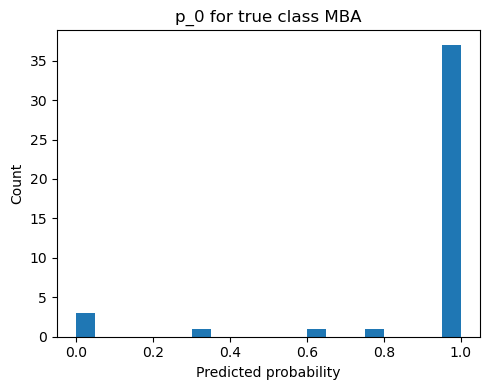

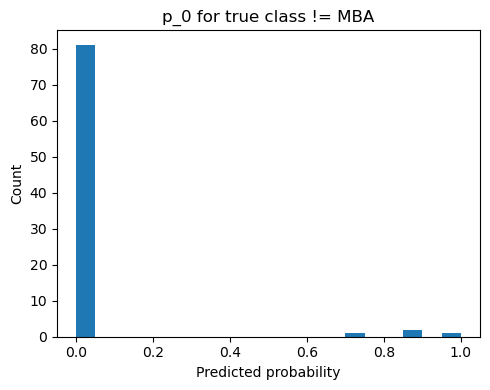

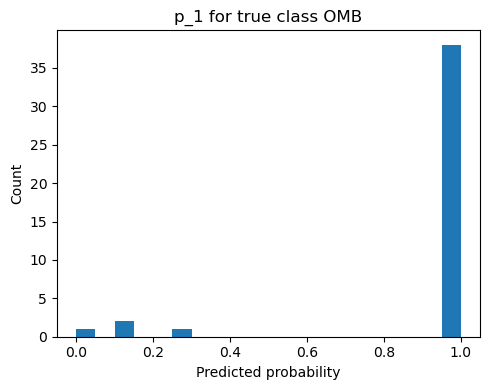

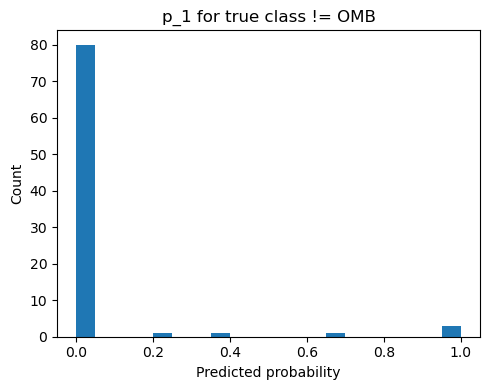

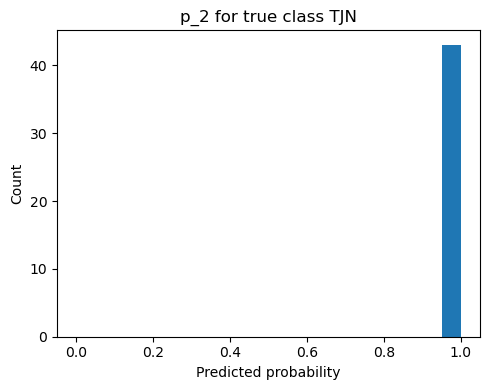

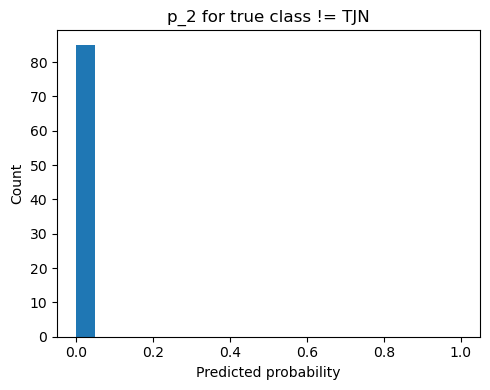

In [7]:
y_pred = np.argmax(p_te, axis=1)

acc = accuracy(y_test, y_pred)
acc_per_class = per_class_accuracy(y_test, y_pred, n_classes=3)

print("Test accuracy:", acc)
print("Per-class accuracy:")
for q, name in enumerate(CLASSES):
    print(f"  {name} (class {q}): {acc_per_class[q]}")

bins = np.linspace(0, 1, 21)

for q, name in enumerate(CLASSES):
    pq = p_te[:, q]
    pos = (y_test == q)
    neg = ~pos

    plt.figure(figsize=(5, 4))
    plt.hist(pq[pos], bins=bins)
    plt.title(f"p_{q} for true class {name}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5, 4))
    plt.hist(pq[neg], bins=bins)
    plt.title(f"p_{q} for true class != {name}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


As shown above, the model performs very well on predicting class TJN, it has an accuracy of 1.0. It does not perform very well on MBA and OMB, only with accuracy of about 0.9.

<a name="task-32"></a>

## (3.2) [(index)](#index-task-32)

In [8]:
def one_hot(y, Q=3):
    N = y.shape[0]
    Y = np.zeros((N, Q))
    Y[np.arange(N), y] = 1.0
    return Y

def mse_loss(Yhat, T):
    # mean squared error
    return np.mean((Yhat - T) ** 2)

def backprop_mse(mlp, forward_pass, Yhat, T):
    """
    Loss: (1/N) * sum ||Yhat - T||^2
    """
    L = len(mlp.layers)
    K = Yhat.shape[0]

    grads_W = [None] * L
    grads_b = [None] * L

    dH = (2.0 / K) * (Yhat - T)

    for j in range(L-1, -1, -1):
        a_j = forward_pass[j+1]["a"]
        h_prev = forward_pass[j]["h"]
        W_j = mlp.layers[j]["W"]

        act = mlp.layers[j]["activation"]
        dact = grad_activation_table[act](a_j)

        dA = dH * dact

        grads_W[j] = (dA.T @ h_prev)
        grads_b[j] = np.mean(dA, axis=0)

        dH = dA @ W_j

    grads = [{"W": grads_W[k], "b": grads_b[k]} for k in range(L)]
    return grads

def train_weak_mlp_mse(X_tr, T_tr, seed_init=2, seed_sgd=42,
                       lr=0.05, batch_size=32, epochs=1000):

    rng_sgd = np.random.default_rng(seed_sgd)

    weak = MLP(seed=seed_init)

    weak.add_layer(7,  32, "relu")
    weak.add_layer(32, 32, "relu")
    weak.add_layer(32, 16, "identity")
    weak.add_layer(16, 3,  "identity")

    N = X_tr.shape[0]

    for ep in range(epochs):
        perm = rng_sgd.permutation(N)

        for s in range(0, N, batch_size):
            idx = perm[s:s+batch_size]
            Xb = X_tr[idx]
            Tb = T_tr[idx]

            Yhat, fwd = weak.predict(Xb)
            grads = backprop_mse(weak, fwd, Yhat, Tb)

            # SGD update
            for k in range(len(weak.layers)):
                weak.layers[k]["W"] -= lr * grads[k]["W"]
                weak.layers[k]["b"] -= lr * grads[k]["b"]

    return weak

M = 4
nu = 2
lr_w = 0.05
bs_w = 32
epochs_w = 1000

a_train, forward_pass_train = mlp.predict(X_train)
a_test, forward_pass_test = mlp.predict(X_test)

Y_train_oh = one_hot(y_train, Q=3)



for t in range(M):
    P_train = softmax(a_train)
    G_train = Y_train_oh - P_train

    weak_t = train_weak_mlp_mse(
        X_train, G_train,
        seed_init=2, seed_sgd=42,
        lr=lr_w, batch_size=bs_w, epochs=epochs_w
    )

    delta_train,forward_pass_train = weak_t.predict(X_train)
    delta_test,forward_pass_test = weak_t.predict(X_test)

    # Update strong logits
    a_train = a_train + nu * delta_train
    a_test  = a_test  + nu * delta_test

    P_test = softmax(a_test)
    y_pred = np.argmax(P_test, axis=1)

    ACC_c = per_class_accuracy(y_test, y_pred, n_classes=3)

    print(f"Iteration {t+1}/{M}: per-class accuracy")
    print(f"  MBA (0): {ACC_c[0]:.4f}")
    print(f"  OMB (1): {ACC_c[1]:.4f}")
    print(f"  TJN (2): {ACC_c[2]:.4f}")
    print("-"*40)

Iteration 1/4: per-class accuracy
  MBA (0): 0.9070
  OMB (1): 0.9048
  TJN (2): 1.0000
----------------------------------------
Iteration 2/4: per-class accuracy
  MBA (0): 0.9070
  OMB (1): 0.9048
  TJN (2): 1.0000
----------------------------------------
Iteration 3/4: per-class accuracy
  MBA (0): 0.9070
  OMB (1): 0.9048
  TJN (2): 1.0000
----------------------------------------
Iteration 4/4: per-class accuracy
  MBA (0): 0.9070
  OMB (1): 0.9048
  TJN (2): 1.0000
----------------------------------------
